In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn modules
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# Load data

In [2]:
df = pd.read_csv(r"C:\Users\User\Downloads\online_shoppers_intention.csv")

# Encoding

In [4]:
# Encode categorical variables, dropping the target 'Revenue' first
df_encoded = pd.get_dummies(df.drop(columns=['Revenue']), drop_first=True)
# Convert the target column 'Revenue' to integer (True/False becomes 1/0)
df_encoded['Revenue'] = df['Revenue'].astype(int)

# Define Features (X) and Target (y)

In [6]:
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

# Split & Scale

In [7]:
# 90/10 train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

# Standard Scaling

In [8]:
scaler = StandardScaler()
# Fit only on training data
X_train = scaler.fit_transform(X_train_raw)
# Transform test data using training statistics
X_test = scaler.transform(X_test_raw)

# Initialize & Cross-Validate Baseline Models

In [9]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("--- Cross Validation Scores (Accuracy) ---")
cv_scores_lr = cross_val_score(lr_model, X_train, y_train, cv=cv, scoring='accuracy')
cv_scores_dt = cross_val_score(dt_model, X_train, y_train, cv=cv, scoring='accuracy')
print(f"Logistic Regression CV: {cv_scores_lr.mean():.4f}")
print(f"Decision Tree CV: {cv_scores_dt.mean():.4f}")

--- Cross Validation Scores (Accuracy) ---
Logistic Regression CV: 0.8848
Decision Tree CV: 0.9029


# Train Baseline Models (Full Training Set)

In [10]:
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# SVM Implementation (Optimized with Sampling)

In [11]:
# Create a 10% sample of the training data for faster GridSearch
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=0.1, stratify=y_train, random_state=42
)

In [12]:
# Define parameters
param_grid_svc = {
    'C': [1, 10, 100],
    'kernel': ['rbf', 'linear', 'poly']
}

In [13]:
# GridSearch (on sample)
grid_svc = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svc,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_svc.fit(X_train_sample, y_train_sample)

print(f"Best Params found: {grid_svc.best_params_}")

Best Params found: {'C': 1, 'kernel': 'linear'}


# Train final SVM on FULL training data using best parameters

In [14]:
best_svc_model = grid_svc.best_estimator_
best_svc_model.fit(X_train, y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# SMOTE Implementation

In [15]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Train Logistic Regression (SMOTE)
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

# Train Decision Tree (SMOTE)
dt_smote = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_smote.fit(X_train_smote, y_train_smote)

# Train SVM (SMOTE) - Using best params from earlier
svc_smote = SVC(
    C=grid_svc.best_params_['C'],
    kernel=grid_svc.best_params_['kernel'],
    probability=True,
    random_state=42
)
print("Training SVM with SMOTE (this may take a moment)...")
svc_smote.fit(X_train_smote, y_train_smote)

Training SVM with SMOTE (this may take a moment)...


,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# Evaluation Helper Function

In [16]:
def evaluate_results(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name} Evaluation")
    print("-" * (len(name) + 11))
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.2%}")
    print(f"Precision : {precision_score(y_test, y_pred):.2%}")
    print(f"Recall : {recall_score(y_test, y_pred):.2%}")
    print(f"F1 Score : {f1_score(y_test, y_pred):.2%}")
    print(f"AUC Score : {roc_auc_score(y_test, y_prob):.2%}")
    print("Confusion Matrix:")
    print(cm)

    return y_prob, roc_auc_score(y_test, y_prob)

# Evaluate All Models

In [18]:
# Baseline Evaluations
y_prob_lr, auc_lr = evaluate_results("LR (Base)", lr_model, X_test, y_test)
y_prob_dt, auc_dt = evaluate_results("DT (Base)", dt_model, X_test, y_test)
y_prob_svc, auc_svc = evaluate_results("SVM (Base)", best_svc_model, X_test, y_test)


LR (Base) Evaluation
--------------------
Accuracy : 88.08%
Precision : 72.92%
Recall : 36.65%
F1 Score : 48.78%
AUC Score : 90.18%
Confusion Matrix:
[[1016   26]
 [ 121   70]]

DT (Base) Evaluation
--------------------
Accuracy : 89.94%
Precision : 73.76%
Recall : 54.45%
F1 Score : 62.65%
AUC Score : 91.73%
Confusion Matrix:
[[1005   37]
 [  87  104]]

SVM (Base) Evaluation
---------------------
Accuracy : 87.83%
Precision : 69.90%
Recall : 37.70%
F1 Score : 48.98%
AUC Score : 87.59%
Confusion Matrix:
[[1011   31]
 [ 119   72]]


In [19]:
# SMOTE Evaluations
y_prob_lr_smote, auc_lr_smote = evaluate_results("LR (SMOTE)", lr_smote, X_test, y_test)
y_prob_dt_smote, auc_dt_smote = evaluate_results("DT (SMOTE)", dt_smote, X_test, y_test)
y_prob_svc_smote, auc_svc_smote = evaluate_results("SVM (SMOTE)", svc_smote, X_test, y_test)


LR (SMOTE) Evaluation
---------------------
Accuracy : 85.16%
Precision : 51.41%
Recall : 76.44%
F1 Score : 61.47%
AUC Score : 90.92%
Confusion Matrix:
[[904 138]
 [ 45 146]]

DT (SMOTE) Evaluation
---------------------
Accuracy : 86.29%
Precision : 53.74%
Recall : 82.72%
F1 Score : 65.15%
AUC Score : 91.37%
Confusion Matrix:
[[906 136]
 [ 33 158]]

SVM (SMOTE) Evaluation
----------------------
Accuracy : 87.02%
Precision : 56.18%
Recall : 73.82%
F1 Score : 63.80%
AUC Score : 91.74%
Confusion Matrix:
[[932 110]
 [ 50 141]]


# ROC Curve (No SMOTE)

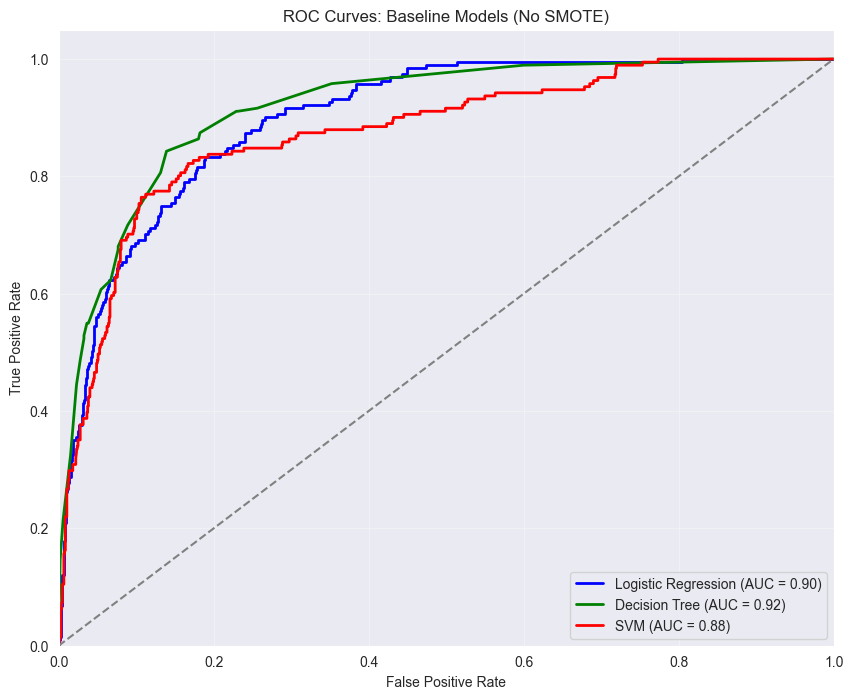

In [20]:
plt.figure(figsize=(10, 8))

# LR
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.2f})')

# DT
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
plt.plot(fpr, tpr, color='green', lw=2, label=f'Decision Tree (AUC = {auc_dt:.2f})')

# SVM
fpr, tpr, _ = roc_curve(y_test, y_prob_svc)
plt.plot(fpr, tpr, color='red', lw=2, label=f'SVM (AUC = {auc_svc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC Curves: Baseline Models (No SMOTE)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


# ROC Curve (SMOTE)

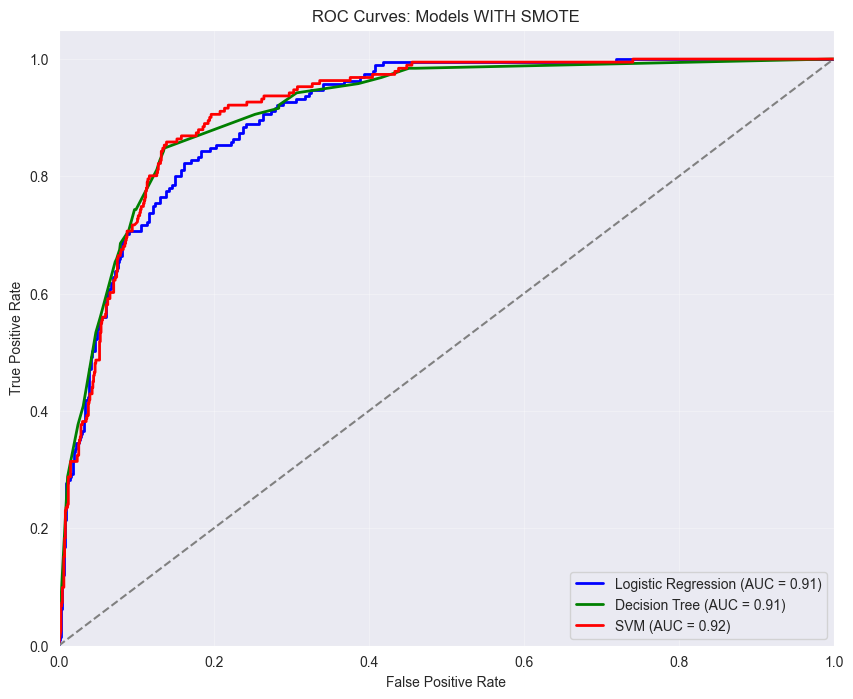

In [21]:
plt.figure(figsize=(10, 8))

# LR SMOTE
fpr, tpr, _ = roc_curve(y_test, y_prob_lr_smote)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_lr_smote:.2f})')

# DT SMOTE
fpr, tpr, _ = roc_curve(y_test, y_prob_dt_smote)
plt.plot(fpr, tpr, color='green', lw=2, label=f'Decision Tree (AUC = {auc_dt_smote:.2f})')

# SVM SMOTE
fpr, tpr, _ = roc_curve(y_test, y_prob_svc_smote)
plt.plot(fpr, tpr, color='red', lw=2, label=f'SVM (AUC = {auc_svc_smote:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC Curves: Models WITH SMOTE')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()